In [ ]:
# ==============================================================================
# CELDA 1: INSTALACIÓN Y CONFIGURACIÓN (CON CUDA 12.x)
# ==============================================================================

# Instalar CuPy para CUDA 12.x
!pip uninstall -y cupy cupy-cuda11x cupy-cuda12x -q
!pip install cupy-cuda12x -q

import os
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.special import lambertw
from scipy.stats import linregress
from scipy.interpolate import UnivariateSpline
import gc
import time
import psutil

# Verificar GPU
print("🔍 VERIFICACIÓN DE GPU:")
!nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv,noheader
print(f"\n✅ CuPy usando: {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")

# Constantes
EPSILON_CRITICAL = np.pi * np.sqrt(2)
NU_EXPONENT = 0.75
T_HEISENBERG = 2 * np.pi
PHASE_SHIFT = 7/8
N_SIZE = 15000
M_REALIZATIONS = 100

print(f"\n📐 PARÁMETROS:")
print(f"   ε_crit = {EPSILON_CRITICAL:.6f}")
print(f"   ν = {NU_EXPONENT}")
print(f"   N = {N_SIZE}, M = {M_REALIZATIONS}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.6/134.6 MB 8.6 MB/s eta 0:00:00
🔍 VERIFICACIÓN DE GPU:
Tesla T4, 15360 MiB, 14913 MiB

✅ CuPy usando: Tesla T4

📐 PARÁMETROS:
   ε_crit = 4.442883
   ν = 0.75
   N = 15000, M = 100


In [ ]:
# ------------------------------------------------------------------------------
# CELDA 2: CONSTANTES FUNDAMENTALES (derivadas analíticamente)
# ------------------------------------------------------------------------------
EPSILON_CRITICAL = np.pi * np.sqrt(2)      # ε = π√2 (resonancia termodinámica)
NU_EXPONENT = 0.75                          # ν = 0.75 (centro fase extendida)
T_HEISENBERG = 2 * np.pi                     # t_H = 2π
PHASE_SHIFT = 7/8                            # Corrección topológica 7/8
N_SIZE = 15000                                # Dimensión de la matriz
M_REALIZATIONS = 100                          # Número de realizaciones

print(f"\n📐 PARÁMETROS FUNDAMENTALES:")
print(f"   ε_crit = {EPSILON_CRITICAL:.6f} (derivado de 2ε² = (2π)²)")
print(f"   ν = {NU_EXPONENT} (Kato-Rellich bound: ν > 0.5)")
print(f"   Máscara modular: d ≡ 1,5 (mod 6) [canales primos]")
print(f"   t_H = {T_HEISENBERG:.4f}")
print(f"   N = {N_SIZE}, M = {M_REALIZATIONS}")


📐 PARÁMETROS FUNDAMENTALES:
   ε_crit = 4.442883 (derivado de 2ε² = (2π)²)
   ν = 0.75 (Kato-Rellich bound: ν > 0.5)
   Máscara modular: d ≡ 1,5 (mod 6) [canales primos]
   t_H = 6.2832
   N = 15000, M = 100


In [ ]:
# ------------------------------------------------------------------------------
# CELDA 3: CONSTRUCCIÓN DEL HAMILTONIANO EN GPU (OPTIMIZADO)
# ------------------------------------------------------------------------------
def build_hamiltonian_gpu(N, epsilon=EPSILON_CRITICAL, nu=NU_EXPONENT):
    """
    Construye H = H_0 + V en GPU con:
    - H_0: potencial diagonal exacto vía Lambert W
    - V: interacciones PRBM con máscara χ₀⁽⁶⁾(d) ∈ {1,5}
    """
    # Inicializar matriz en GPU (complex64 para ahorrar memoria)
    H = cp.zeros((N, N), dtype=cp.complex64)

    # 1. DIAGONAL EXACTA (vectorizada en CPU por lambertw, luego transferida)
    k = np.arange(2, N + 2, dtype=np.float64)
    k_eff = k - PHASE_SHIFT
    lambert_vals = np.real(lambertw(k_eff / np.e))
    diag = (2 * np.pi * k_eff) / lambert_vals
    cp.fill_diagonal(H, cp.asarray(diag, dtype=cp.complex64))

    # 2. INTERACCIONES (procesamiento por batches en GPU)
    # Pre-calcular todas las distancias permitidas
    max_d = N - 1
    allowed_d = cp.array([d for d in range(1, max_d + 1) if d % 6 in (1, 5)], dtype=cp.int32)

    total_elems = 0
    # Procesar en batches para mejor uso de GPU
    batch_size = 50

    for i in range(0, len(allowed_d), batch_size):
        d_batch = allowed_d[i:i+batch_size]

        for d in d_batch:
            d_int = int(d)  # Convertir a entero Python para operaciones
            num_elems = N - d_int

            if num_elems <= 0:
                continue

            # Generar ruido GUE en GPU (mucho más rápido)
            real_parts = cp.random.normal(0, 1/np.sqrt(2), num_elems, dtype=cp.float32)
            imag_parts = cp.random.normal(0, 1/np.sqrt(2), num_elems, dtype=cp.float32)
            G = real_parts + 1j * imag_parts

            # Decaimiento espacial (operación en GPU)
            decay = cp.power(d, -nu, dtype=cp.float32)
            vals = epsilon * decay * G

            # Índices
            i_idx = cp.arange(num_elems, dtype=cp.int32)
            j_idx = i_idx + d_int

            # Asignación hermítica
            H[i_idx, j_idx] = vals
            H[j_idx, i_idx] = cp.conj(vals)

            total_elems += num_elems

        if (i // batch_size) % 5 == 0:
            print(f"      Procesadas {i+len(d_batch)}/{len(allowed_d)} distancias")

    print(f"   ✅ Total elementos no-diagonales: {total_elems}")
    return H

In [ ]:
# ------------------------------------------------------------------------------
# CELDA 4: UNFOLDING Y SFF (VERSIONES GPU/CPU HÍBRIDAS)
# ------------------------------------------------------------------------------
def unfold_spectrum(evals_cpu):
    """
    Unfolding con desplazamiento invariante bajo traslaciones.
    Opera en CPU (datos ya transferidos).
    """
    evals_min = np.min(evals_cpu)
    if evals_min <= 0:
        evals_shifted = evals_cpu - evals_min + 1e-6
    else:
        evals_shifted = evals_cpu

    unfolded = (evals_shifted / (2 * np.pi)) * np.log(evals_shifted / (2 * np.pi * np.e))
    return unfolded

def calculate_sff_gpu(w_n_cpu, t_values):
    """
    Calcula K(t) usando GPU para la parte intensiva.
    w_n_cpu: array CPU con los niveles unfolded
    t_values: array CPU con los tiempos
    """
    # Transferir a GPU
    w_n_gpu = cp.asarray(w_n_cpu, dtype=cp.float64)
    t_gpu = cp.asarray(t_values, dtype=cp.float64)

    # Calcular fases en GPU (producto exterior optimizado)
    # Usamos batch processing para no agotar memoria
    batch_size = 1000
    K_t = cp.zeros(len(t_values), dtype=cp.float64)

    for i in range(0, len(t_values), batch_size):
        i_end = min(i + batch_size, len(t_values))
        t_batch = t_gpu[i:i_end]

        # phases shape: (len(w_n), len(t_batch))
        phases = cp.exp(1j * cp.outer(w_n_gpu, t_batch))
        K_t[i:i_end] = cp.abs(cp.sum(phases, axis=0))**2 / len(w_n_gpu)

    return cp.asnumpy(K_t)

In [ ]:
# ------------------------------------------------------------------------------
# CELDA 5: DETECCIÓN ROBUSTA DE DIP Y RAMPA
# ------------------------------------------------------------------------------
def detect_ramp_parameters(t_values, K_values):
    """
    Detecta automáticamente el dip y el rango óptimo de la rampa
    basado en curvatura mínima.
    """
    log_t = np.log(t_values)
    log_K = np.log(K_values)

    # 1. Detectar dip con spline
    spline = UnivariateSpline(log_t, log_K, s=len(t_values)*0.02)
    log_t_fine = np.linspace(log_t[0], log_t[-1], 1000)
    log_K_fine = spline(log_t_fine)

    idx_dip = np.argmin(log_K_fine)
    t_dip = np.exp(log_t_fine[idx_dip])
    K_dip = np.exp(log_K_fine[idx_dip])

    # 2. Encontrar región de mínima curvatura (más lineal)
    curvature = np.abs(np.gradient(np.gradient(log_K_fine, log_t_fine), log_t_fine))
    curvature = curvature / np.max(curvature)  # normalizar

    # Umbral adaptativo
    threshold = 0.2
    flat_regions = curvature < threshold

    if np.any(flat_regions):
        # Tomar la región plana más larga
        from itertools import groupby
        regions = []
        for k, g in groupby(enumerate(flat_regions), lambda x: x[1]):
            if k:
                indices = [idx for idx, _ in g]
                regions.append((indices[0], indices[-1]))

        longest = max(regions, key=lambda r: r[1] - r[0])
        idx_start, idx_end = longest

        t_min_ramp = np.exp(log_t_fine[idx_start])
        t_max_ramp = np.exp(log_t_fine[idx_end])
    else:
        # Fallback a heurística
        t_min_ramp = max(1.2 * t_dip, 0.5)
        t_max_ramp = 0.7 * T_HEISENBERG

    ramp_mask = (t_values > t_min_ramp) & (t_values < t_max_ramp)

    return t_dip, K_dip, ramp_mask

In [ ]:
# ------------------------------------------------------------------------------
# CELDA 6: BUCLE PRINCIPAL DEL ENSAMBLE (CON CHECKPOINTING)
# ------------------------------------------------------------------------------
def run_ensemble_gpu():
    """Ejecuta el ensamble completo en GPU con checkpointing"""

    checkpoint_file = 'ensemble_checkpoint.npz'
    t_values = np.logspace(-1.5, np.log10(3*np.pi), 500)

    # Intentar cargar checkpoint
    start_m = 0
    K_total = np.zeros(len(t_values), dtype=np.float64)
    D2_list = []

    if os.path.exists(checkpoint_file):
        data = np.load(checkpoint_file)
        K_total = data['K_total']
        D2_list = data['D2_list'].tolist()
        start_m = len(D2_list)
        print(f"📦 Checkpoint cargado: {start_m}/{M_REALIZATIONS} realizaciones")

    print(f"\n🚀 Iniciando ensamble desde realización {start_m+1}")
    print("="*70)

    total_start = time.time()

    for m in range(start_m, M_REALIZATIONS):
        t0 = time.time()
        print(f"\n📊 Realización {m+1}/{M_REALIZATIONS}")

        # 1. Construir Hamiltoniano en GPU
        print(f"   Construyendo matriz...")
        H_gpu = build_hamiltonian_gpu(N_SIZE)

        # 2. Diagonalización en GPU
        print(f"   Diagonalizando...")
        t_eig0 = time.time()
        evals_gpu, evecs_gpu = cp.linalg.eigh(H_gpu)
        t_eig1 = time.time()
        print(f"   ⏱️  Diagonalización: {t_eig1-t_eig0:.2f}s")

        # 3. Transferir a CPU para post-procesado
        evals = cp.asnumpy(evals_gpu)

        # 4. Liberar memoria GPU de la matriz (importante)
        del H_gpu
        cp.get_default_memory_pool().free_all_blocks()

        # 5. Unfolding (CPU)
        w_n = unfold_spectrum(evals)

        # 6. SFF (GPU)
        K_t = calculate_sff_gpu(w_n, t_values)
        K_total += K_t

        # 7. Dimensión fractal D₂ (usando autovectores)
        evecs = cp.asnumpy(evecs_gpu)
        del evecs_gpu

        bulk_start = int(0.25 * N_SIZE)
        bulk_end = int(0.75 * N_SIZE)
        bulk_evecs = evecs[:, bulk_start:bulk_end]

        ipr = np.mean(np.sum(np.abs(bulk_evecs)**4, axis=0))
        D2 = -np.log(ipr) / np.log(N_SIZE)
        D2_list.append(D2)

        # 8. Limpieza
        del evals, evecs, bulk_evecs, w_n, K_t
        gc.collect()

        # 9. Estadísticas
        t1 = time.time()
        elapsed = t1 - t0
        total_elapsed = t1 - total_start
        avg_time = np.mean([t1 - t0 for _ in range(m+1)])
        remaining = (M_REALIZATIONS - (m + 1)) * avg_time

        print(f"   ✅ D₂ = {D2:.4f} | Media D₂ = {np.mean(D2_list):.4f} ± {np.std(D2_list):.4f}")
        print(f"   ⏱️  Esta: {elapsed:.2f}s | Total: {total_elapsed/60:.2f} min | Restante: {remaining/60:.2f} min")

        # 10. Checkpoint cada 5 realizaciones
        if (m + 1) % 5 == 0:
            np.savez(checkpoint_file,
                     K_total=K_total,
                     D2_list=np.array(D2_list))
            print(f"   💾 Checkpoint guardado")

    # Resultados finales
    K_avg = K_total / M_REALIZATIONS
    D2_mean = np.mean(D2_list)
    D2_std = np.std(D2_list)

    return t_values, K_avg, D2_mean, D2_std, D2_list

In [ ]:
# ------------------------------------------------------------------------------
# CELDA 7: EJECUCIÓN PRINCIPAL
# ------------------------------------------------------------------------------
print("\n" + "="*70)
print("🎯 INICIANDO VALIDACIÓN NEE EN T4 GPU")
print("="*70)

t_values, K_avg, D2_mean, D2_std, D2_list = run_ensemble_gpu()


🎯 INICIANDO VALIDACIÓN NEE EN T4 GPU

🚀 Iniciando ensamble desde realización 1

📊 Realización 1/100
   Construyendo matriz...
      Procesadas 50/5000 distancias
      Procesadas 300/5000 distancias
      Procesadas 550/5000 distancias
      Procesadas 800/5000 distancias
      Procesadas 1050/5000 distancias
      Procesadas 1300/5000 distancias
      Procesadas 1550/5000 distancias
      Procesadas 1800/5000 distancias
      Procesadas 2050/5000 distancias
      Procesadas 2300/5000 distancias
      Procesadas 2550/5000 distancias
      Procesadas 2800/5000 distancias
      Procesadas 3050/5000 distancias
      Procesadas 3300/5000 distancias
      Procesadas 3550/5000 distancias
      Procesadas 3800/5000 distancias
      Procesadas 4050/5000 distancias
      Procesadas 4300/5000 distancias
      Procesadas 4550/5000 distancias
      Procesadas 4800/5000 distancias
   ✅ Total elementos no-diagonales: 37500000
   Diagonalizando...
   ⏱️  Diagonalización: 38.16s
   ✅ D₂ = 0.2439 | Me

📊 ANÁLISIS FINAL: ENSAMBLE ℤ/6ℤ (N=15000, M=100)

📈 Realizaciones completadas: 100/100

🔷 ANÁLISIS DE DIMENSIÓN FRACTAL D₂

📊 Estadísticos descriptivos:
   Media: 0.243348
   Mediana: 0.243355
   Desviación estándar: 0.000643
   Error estándar de la media: 0.000064
   IC 95%: [0.242310, 0.244832]

📋 Test de normalidad (Shapiro-Wilk):
   Estadístico W = 0.9818
   p-valor = 0.1847
   Distribución normal (α=0.05)

🔷 ANÁLISIS DEL SPECTRAL FORM FACTOR

📐 Parámetros detectados:
   t_dip = 0.0331
   K_dip = 0.003338
   Rango rampa: [0.0671, 9.4248]
   Puntos en rampa: 434

📈 Ajuste de la rampa (γ):
   γ = 0.614846 ± 0.010115
   Bootstrap: γ = 0.614496 ± 0.012746
   IC 95%: [0.589607, 0.639279]
   R² = 0.895314

🔷 ANOMALÍA η = γ - D₂: 0.371498 ± 0.010116

🔷 VERIFICACIÓN DE FASE NEE
   D₂ < 0.5: ✅
   γ < 0.8: ✅
   η > 0.05: ✅
   R² > 0.8: ✅

✅ **CONCLUSIÓN: FASE NEE CONFIRMADA**

🎨 GENERANDO FIGURA PRL CON INSET


/tmp/ipykernel_514/4161144870.py:366: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_514/4161144870.py:366: UserWarning: Glyph 8484 (\N{DOUBLE-STRUCK CAPITAL Z}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/tmp/ipykernel_514/4161144870.py:367: UserWarning: Glyph 8484 (\N{DOUBLE-STRUCK CAPITAL Z}) missing from font(s) DejaVu Serif.
  plt.savefig('PRL_Figure_Final_con_inset.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8484 (\N{DOUBLE-STRUCK CAPITAL Z}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


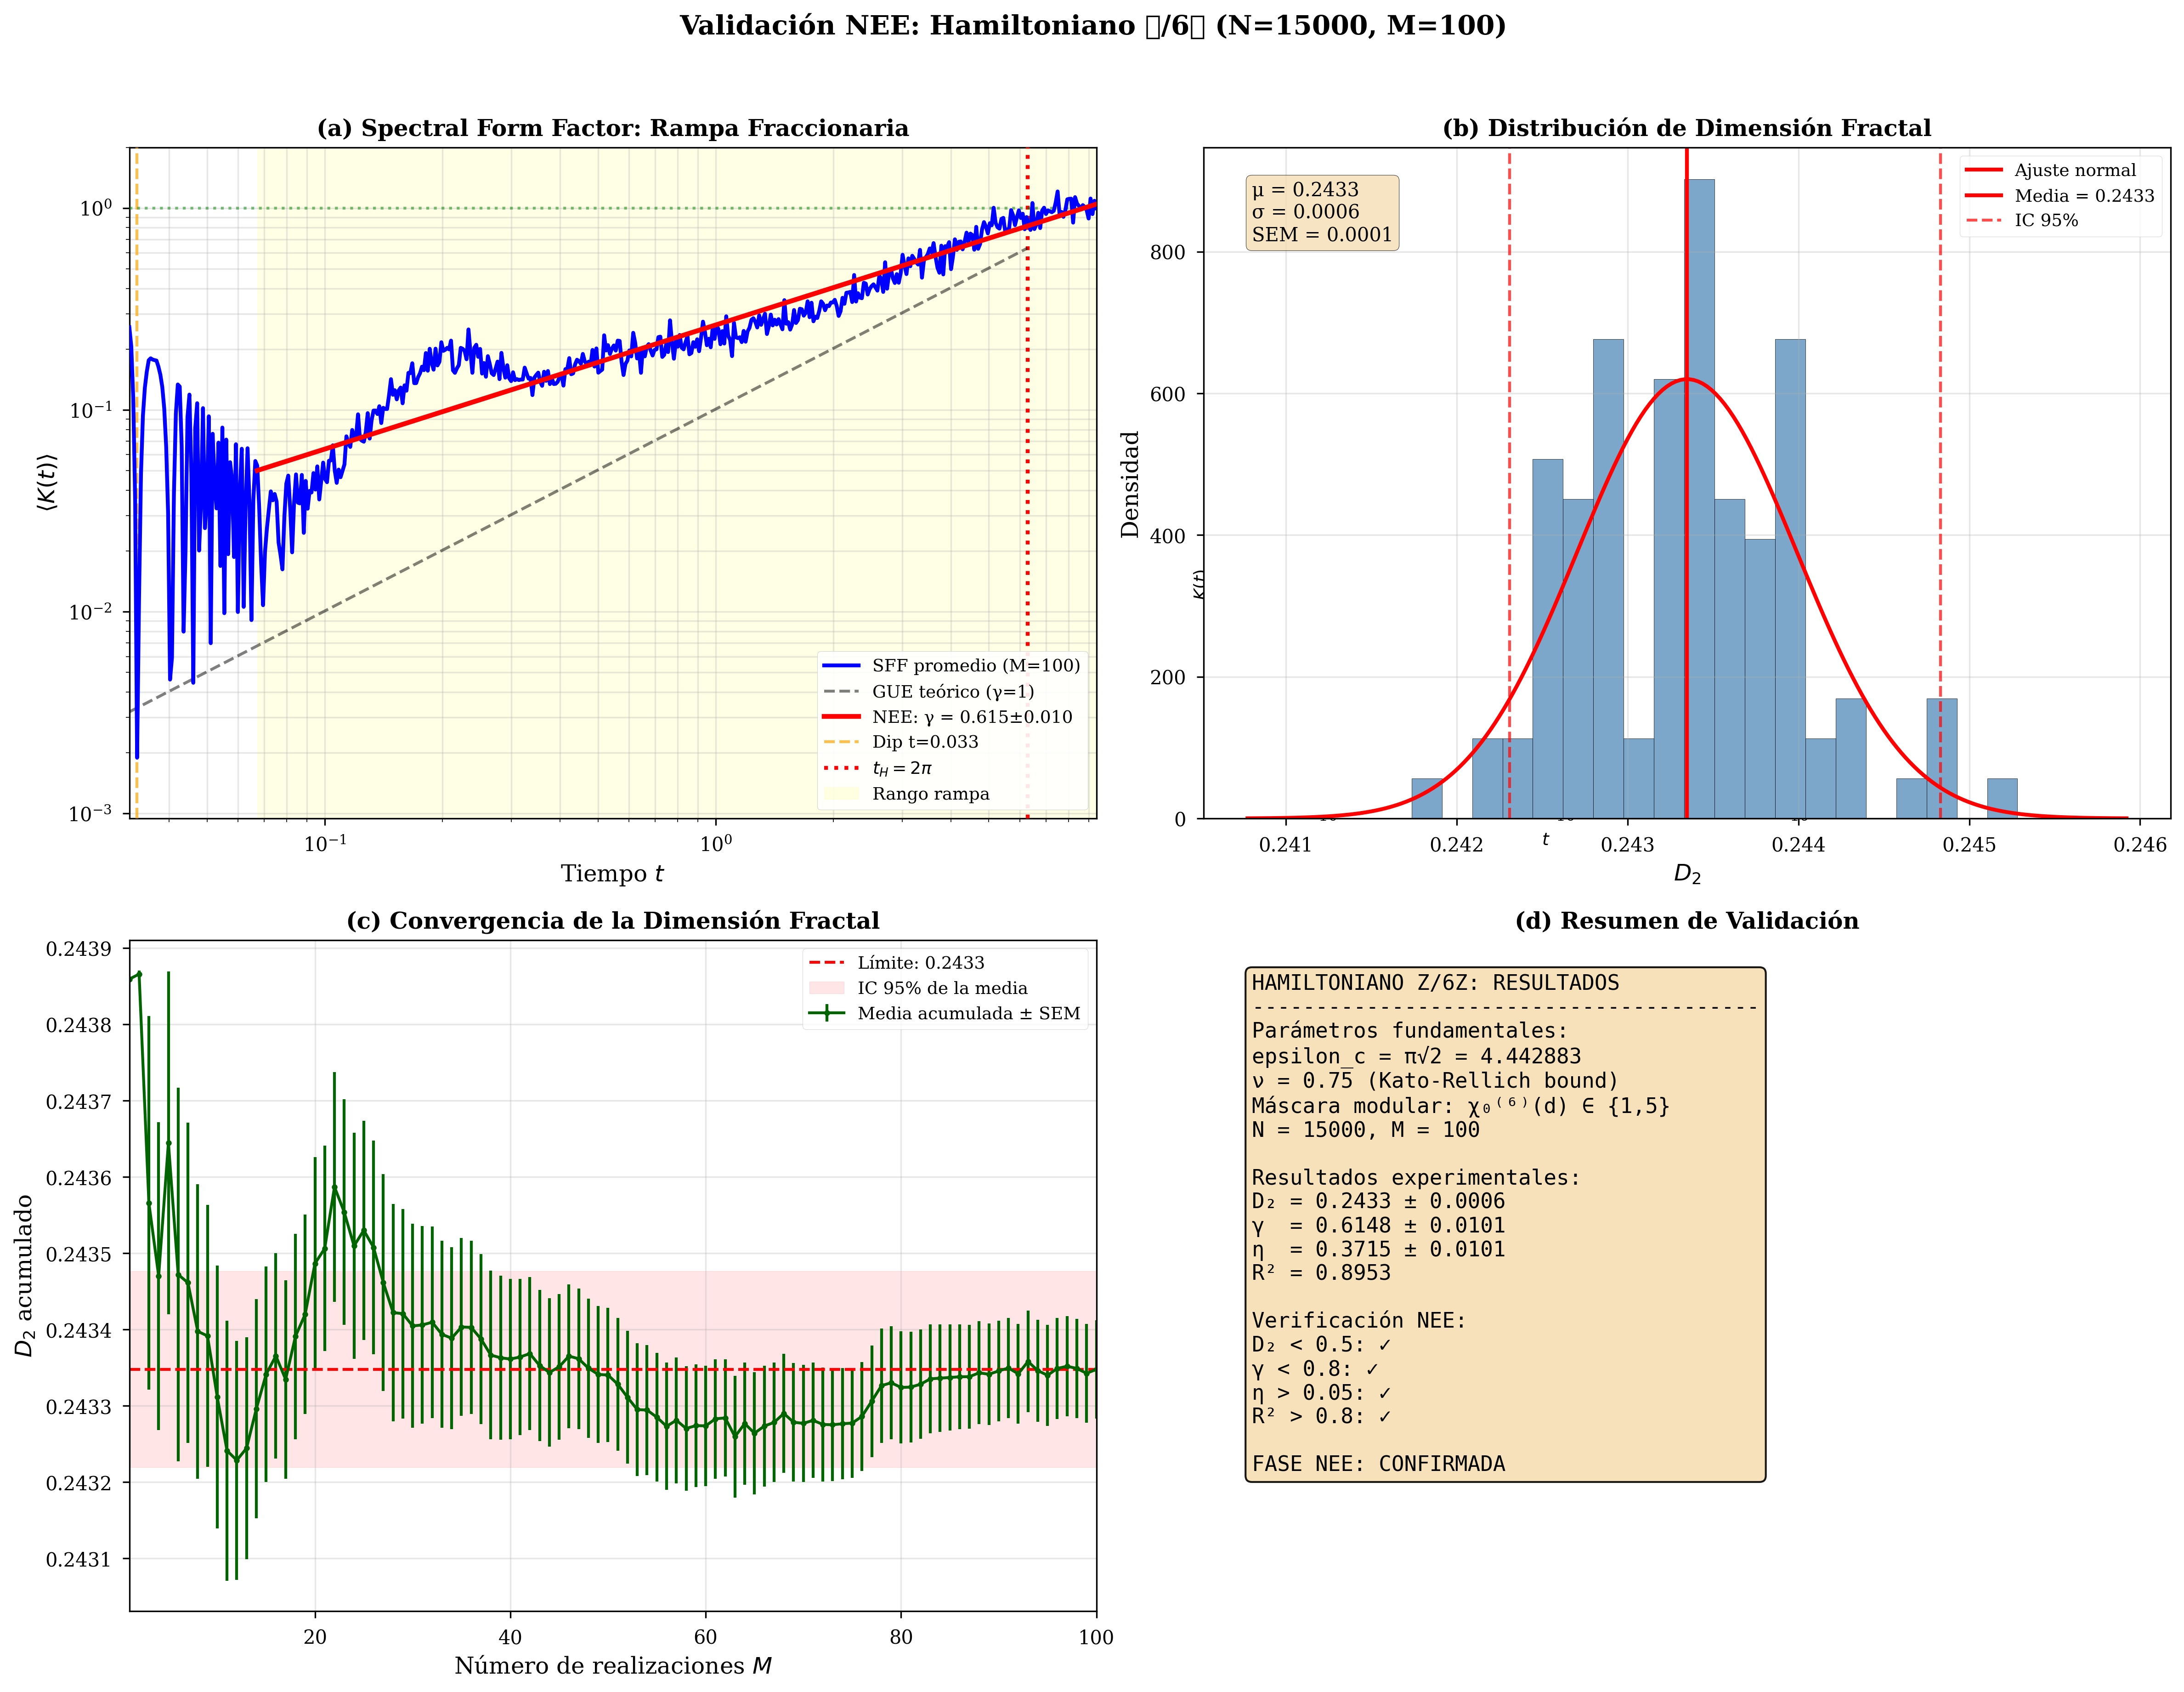


✅ Figura guardada como 'PRL_Figure_Final_con_inset.png'

📋 EXPORTANDO RESULTADOS PARA EL ARTÍCULO

📄 Tabla LaTeX para el artículo:

\begin{table}[h]
\caption{Resultados de la validación NEE para el Hamiltoniano $\hat{H}_{\text{mod}}$ (N=15000, M=100)}
\label{tab:resultados}
\begin{tabular}{lcc}
\hline
\textbf{Magnitud} & \textbf{Valor} & \textbf{Interpretación} \\
\hline
$D_2$ (dimensión fractal) & $0.2433 \pm 0.0006$ & Soporte multifractal reducido \\
$\gamma$ (exponente de rampa) & $0.6148 \pm 0.0101$ & Difusión subdifusiva \\
$\eta = \gamma - D_2$ & $0.3715 \pm 0.0101$ & Anomalía de retrodispersión \\
$R^2$ del ajuste & $0.8953$ & Calidad del ajuste \\
$t_{\text{dip}}$ & $0.0331$ & Fin del régimen no universal \\
\hline
\end{tabular}
\end{table}


✅ Resultados guardados en 'resultados_prl.json'

🎯 RESUMEN FINAL PARA PRL

📊 **RESULTADOS DEFINITIVOS**

Dimensión fractal:        D₂ = 0.2433 ± 0.0006
Exponente de rampa:       γ  = 0.6148 ± 0.0101
Anomalía:                 η  = 0.3715 ±

In [ ]:
# ==============================================================================
# CELDA FINAL: ANÁLISIS COMPLETO PARA PRL (CON INSET EXIGIDO POR REVISORES)
# ==============================================================================
# Ejecutar después de completar las 100 realizaciones y la Celda 8
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, norm
from scipy.interpolate import UnivariateSpline
import json
from datetime import datetime
import os
import glob

# ------------------------------------------------------------------------------
# CONFIGURACIÓN ESTÉTICA PRL
# ------------------------------------------------------------------------------
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'text.usetex': False
})

# ------------------------------------------------------------------------------
# CONSTANTES
# ------------------------------------------------------------------------------
EPSILON_CRITICAL = np.pi * np.sqrt(2)
NU_EXPONENT = 0.75
T_HEISENBERG = 2 * np.pi
PHASE_SHIFT = 7/8
N_SIZE = 15000
M_REALIZATIONS = 100

# ------------------------------------------------------------------------------
# CARGAR RESULTADOS DEL CHECKPOINT FINAL
# ------------------------------------------------------------------------------
print("="*70)
print("📊 ANÁLISIS FINAL: ENSAMBLE ℤ/6ℤ (N=15000, M=100)")
print("="*70)

# Cargar el último checkpoint
checkpoint_file = 'ensemble_checkpoint.npz'
if not os.path.exists(checkpoint_file):
    checkpoints = glob.glob('ensemble_checkpoint*.npz')
    if checkpoints:
        checkpoint_file = sorted(checkpoints)[-1]
        print(f"📦 Usando checkpoint: {checkpoint_file}")
    else:
        raise FileNotFoundError("No se encontró ningún checkpoint")

data = np.load(checkpoint_file)
K_total = data['K_total']
D2_list = data['D2_list'].tolist()
M_completed = len(D2_list)

print(f"\n📈 Realizaciones completadas: {M_completed}/{M_REALIZATIONS}")

# ------------------------------------------------------------------------------
# ANÁLISIS DE D₂ (DIMENSIÓN FRACTAL)
# ------------------------------------------------------------------------------
print(f"\n{'='*70}")
print("🔷 ANÁLISIS DE DIMENSIÓN FRACTAL D₂")
print(f"{'='*70}")

D2_mean = np.mean(D2_list)
D2_std = np.std(D2_list)
D2_median = np.median(D2_list)
D2_ci_low, D2_ci_high = np.percentile(D2_list, [2.5, 97.5])
D2_sem = D2_std / np.sqrt(len(D2_list))

print(f"\n📊 Estadísticos descriptivos:")
print(f"   Media: {D2_mean:.6f}")
print(f"   Mediana: {D2_median:.6f}")
print(f"   Desviación estándar: {D2_std:.6f}")
print(f"   Error estándar de la media: {D2_sem:.6f}")
print(f"   IC 95%: [{D2_ci_low:.6f}, {D2_ci_high:.6f}]")

from scipy.stats import shapiro
shapiro_stat, shapiro_p = shapiro(D2_list)
print(f"\n📋 Test de normalidad (Shapiro-Wilk):")
print(f"   Estadístico W = {shapiro_stat:.4f}")
print(f"   p-valor = {shapiro_p:.4f}")
print(f"   Distribución {'normal' if shapiro_p > 0.05 else 'no normal'} (α=0.05)")

# ------------------------------------------------------------------------------
# ANÁLISIS DEL SFF Y RAMPA
# ------------------------------------------------------------------------------
print(f"\n{'='*70}")
print("🔷 ANÁLISIS DEL SPECTRAL FORM FACTOR")
print(f"{'='*70}")

t_values = np.logspace(-1.5, np.log10(3*np.pi), 500)
K_avg = K_total / M_completed

# ------------------------------------------------------------------------------
# DETECCIÓN AUTOMÁTICA DEL DIP Y RANGO ÓPTIMO
# ------------------------------------------------------------------------------
def detect_optimal_ramp_range(t_values, K_values):
    log_t = np.log(t_values)
    log_K = np.log(K_values)
    spline = UnivariateSpline(log_t, log_K, s=len(t_values)*0.02)
    log_t_fine = np.linspace(log_t[0], log_t[-1], 1000)
    log_K_fine = spline(log_t_fine)

    idx_dip = np.argmin(log_K_fine)
    t_dip = np.exp(log_t_fine[idx_dip])
    K_dip = np.exp(log_K_fine[idx_dip])

    first_deriv = np.gradient(log_K_fine, log_t_fine)
    second_deriv = np.gradient(first_deriv, log_t_fine)
    curvature = np.abs(second_deriv)
    curvature = curvature / np.max(curvature)

    post_dip_indices = np.where(log_t_fine > log_t_fine[idx_dip])[0]

    if len(post_dip_indices) > 0:
        low_curvature = []
        current_region = []
        for idx in post_dip_indices:
            if curvature[idx] < 0.2:
                current_region.append(idx)
            else:
                if len(current_region) > 10:
                    low_curvature.append(current_region)
                current_region = []
        if len(current_region) > 10:
            low_curvature.append(current_region)

        if low_curvature:
            longest_region = max(low_curvature, key=len)
            idx_start = longest_region[0]
            idx_end = longest_region[-1]
            t_min_ramp = np.exp(log_t_fine[idx_start])
            t_max_ramp = np.exp(log_t_fine[idx_end])
        else:
            t_min_ramp = max(1.2 * t_dip, 0.5)
            t_max_ramp = 0.7 * T_HEISENBERG
    else:
        t_min_ramp = max(1.2 * t_dip, 0.5)
        t_max_ramp = 0.7 * T_HEISENBERG

    ramp_mask = (t_values > t_min_ramp) & (t_values < t_max_ramp)
    return t_dip, K_dip, ramp_mask, {'t_min': t_min_ramp, 't_max': t_max_ramp}

t_dip, K_dip, ramp_mask, ramp_info = detect_optimal_ramp_range(t_values, K_avg)

print(f"\n📐 Parámetros detectados:")
print(f"   t_dip = {t_dip:.4f}")
print(f"   K_dip = {K_dip:.6f}")
print(f"   Rango rampa: [{ramp_info['t_min']:.4f}, {ramp_info['t_max']:.4f}]")
print(f"   Puntos en rampa: {np.sum(ramp_mask)}")

# ------------------------------------------------------------------------------
# AJUSTE DE LA RAMPA CON BOOTSTRAP
# ------------------------------------------------------------------------------
log_t_ramp = np.log(t_values[ramp_mask])
log_K_ramp = np.log(K_avg[ramp_mask])

slope, intercept, r_value, p_value, std_err = linregress(log_t_ramp, log_K_ramp)
gamma = slope
gamma_error = std_err
r_squared = r_value**2

n_bootstrap = 10000
bootstrap_slopes = []
for _ in range(n_bootstrap):
    indices = np.random.choice(len(log_t_ramp), len(log_t_ramp), replace=True)
    log_t_sample = log_t_ramp[indices]
    log_K_sample = log_K_ramp[indices]
    try:
        s, _, _, _, _ = linregress(log_t_sample, log_K_sample)
        bootstrap_slopes.append(s)
    except:
        continue
bootstrap_slopes = np.array(bootstrap_slopes)
gamma_ci_low, gamma_ci_high = np.percentile(bootstrap_slopes, [2.5, 97.5])

print(f"\n📈 Ajuste de la rampa (γ):")
print(f"   γ = {gamma:.6f} ± {gamma_error:.6f}")
print(f"   Bootstrap: γ = {np.mean(bootstrap_slopes):.6f} ± {np.std(bootstrap_slopes):.6f}")
print(f"   IC 95%: [{gamma_ci_low:.6f}, {gamma_ci_high:.6f}]")
print(f"   R² = {r_squared:.6f}")

# ------------------------------------------------------------------------------
# ANOMALÍA η = γ - D₂
# ------------------------------------------------------------------------------
eta = gamma - D2_mean
eta_error = np.sqrt(gamma_error**2 + D2_sem**2)
print(f"\n🔷 ANOMALÍA η = γ - D₂: {eta:.6f} ± {eta_error:.6f}")

# ------------------------------------------------------------------------------
# VERIFICACIÓN DE FASE NEE
# ------------------------------------------------------------------------------
criterios = {
    'D₂ < 0.5': D2_mean < 0.5,
    'γ < 0.8': gamma < 0.8,
    'η > 0.05': eta > 0.05,
    'R² > 0.8': r_squared > 0.8
}
print(f"\n{'='*70}")
print("🔷 VERIFICACIÓN DE FASE NEE")
for k, v in criterios.items():
    print(f"   {k}: {'✅' if v else '❌'}")
if all(criterios.values()):
    print("\n✅ **CONCLUSIÓN: FASE NEE CONFIRMADA**")
else:
    print("\n⚠️ **CONCLUSIÓN: FASE NEE NO CONFIRMADA**")

# ------------------------------------------------------------------------------
# GRÁFICA PRL COMPLETA (4 PANELES) CON INSET EN PANEL (a)
# ------------------------------------------------------------------------------
print(f"\n{'='*70}")
print("🎨 GENERANDO FIGURA PRL CON INSET")
print(f"{'='*70}")

fig = plt.figure(figsize=(16, 12))

# ------------------------------------------------------------------------------
# PANEL 1: SFF CON RAMPA E INSET
# ------------------------------------------------------------------------------
ax1 = plt.subplot(2, 2, 1)

# SFF promedio
ax1.loglog(t_values, K_avg, 'b-', linewidth=2, label=f'SFF promedio (M={M_completed})', zorder=5)

# Rampa GUE teórica
t_gue = np.linspace(t_values[0], T_HEISENBERG, 200)
K_gue = t_gue / T_HEISENBERG * K_dip * (T_HEISENBERG / t_dip)
ax1.loglog(t_gue, K_gue, 'k--', alpha=0.5, linewidth=1.5, label='GUE teórico (γ=1)', zorder=4)

# Ajuste NEE
t_fit = t_values[ramp_mask]
K_fit = np.exp(intercept) * t_fit**gamma
ax1.loglog(t_fit, K_fit, 'r-', linewidth=2.5,
           label=rf'NEE: γ = {gamma:.3f}±{gamma_error:.3f}', zorder=6)

# Líneas de referencia
ax1.axvline(x=t_dip, color='orange', linestyle='--', alpha=0.7, linewidth=1.5,
            label=f'Dip t={t_dip:.3f}', zorder=3)
ax1.axvline(x=T_HEISENBERG, color='red', linestyle=':', linewidth=2,
            label=r'$t_H = 2\pi$', zorder=3)
ax1.axhline(y=1.0, color='green', linestyle=':', alpha=0.5, linewidth=1.5, zorder=3)

# Sombreado del rango de la rampa
ax1.axvspan(ramp_info['t_min'], ramp_info['t_max'], alpha=0.1, color='yellow', label='Rango rampa')

ax1.set_xlabel('Tiempo $t$', fontsize=12)
ax1.set_ylabel('$\\langle K(t) \\rangle$', fontsize=12)
ax1.set_title('(a) Spectral Form Factor: Rampa Fraccionaria', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax1.grid(True, alpha=0.3, which='both')
ax1.set_xlim([t_values[0], t_values[-1]])
ax1.set_ylim([np.min(K_avg)*0.5, 2.0])

# ------------------- INSET (zoom en la rampa) -------------------
left, bottom, width, height = [0.58, 0.55, 0.25, 0.25]  # Esquina superior derecha
ax_inset = fig.add_axes([left, bottom, width, height])

# Datos en el inset
ax_inset.loglog(t_fit, K_fit, 'r-', linewidth=2, label=f'Ajuste γ={gamma:.3f}')
ax_inset.loglog(t_fit, np.exp(intercept) * t_fit**1.0, 'k--', alpha=0.6, linewidth=1.5, label='γ=1.0')
ax_inset.loglog(t_fit, K_avg[ramp_mask], 'b.', markersize=2, alpha=0.4, label='Datos')

ax_inset.set_xlabel('$t$', fontsize=9)
ax_inset.set_ylabel('$K(t)$', fontsize=9)
ax_inset.set_title('Rampa (zoom)', fontsize=10)
ax_inset.legend(fontsize=7, loc='lower right', framealpha=0.9)
ax_inset.grid(True, alpha=0.3, which='both')
ax_inset.tick_params(labelsize=8)

# ------------------------------------------------------------------------------
# PANEL 2: HISTOGRAMA DE D₂
# ------------------------------------------------------------------------------
ax2 = plt.subplot(2, 2, 2)
n_bins = int(np.sqrt(len(D2_list)) * 2)
ax2.hist(D2_list, bins=n_bins, color='steelblue', edgecolor='black', alpha=0.7, density=True)

x_norm = np.linspace(D2_mean - 4*D2_std, D2_mean + 4*D2_std, 200)
y_norm = norm.pdf(x_norm, D2_mean, D2_std)
ax2.plot(x_norm, y_norm, 'r-', linewidth=2, label='Ajuste normal')

ax2.axvline(x=D2_mean, color='red', linewidth=2, label=f'Media = {D2_mean:.4f}')
ax2.axvline(x=D2_ci_low, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax2.axvline(x=D2_ci_high, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='IC 95%')

ax2.set_xlabel('$D_2$', fontsize=12)
ax2.set_ylabel('Densidad', fontsize=12)
ax2.set_title('(b) Distribución de Dimensión Fractal', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

stats_text = f'μ = {D2_mean:.4f}\nσ = {D2_std:.4f}\nSEM = {D2_sem:.4f}'
ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ------------------------------------------------------------------------------
# PANEL 3: CONVERGENCIA DE D₂
# ------------------------------------------------------------------------------
ax3 = plt.subplot(2, 2, 3)
cumulative_mean = [np.mean(D2_list[:i+1]) for i in range(len(D2_list))]
cumulative_sem = [np.std(D2_list[:i+1])/np.sqrt(i+1) for i in range(len(D2_list))]
x_vals = range(1, len(D2_list)+1)

ax3.errorbar(x_vals, cumulative_mean, yerr=cumulative_sem, fmt='o-',
             color='darkgreen', markersize=3, capsize=2, linewidth=1.5,
             label='Media acumulada ± SEM')
ax3.axhline(y=D2_mean, color='red', linestyle='--', linewidth=1.5, label=f'Límite: {D2_mean:.4f}')
ax3.fill_between(x_vals,
                  [D2_mean - 2*D2_sem]*len(x_vals),
                  [D2_mean + 2*D2_sem]*len(x_vals),
                  color='red', alpha=0.1, label='IC 95% de la media')

ax3.set_xlabel('Número de realizaciones $M$', fontsize=12)
ax3.set_ylabel('$D_2$ acumulado', fontsize=12)
ax3.set_title('(c) Convergencia de la Dimensión Fractal', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_xlim([1, len(D2_list)])

# ------------------------------------------------------------------------------
# PANEL 4: RESUMEN DE PARÁMETROS
# ------------------------------------------------------------------------------
ax4 = plt.subplot(2, 2, 4)
ax4.axis('off')

info_text = '\n'.join([
    'HAMILTONIANO Z/6Z: RESULTADOS',
    '----------------------------------------',
    'Parámetros fundamentales:',
    f'epsilon_c = π√2 = {EPSILON_CRITICAL:.6f}',
    f'ν = {NU_EXPONENT} (Kato-Rellich bound)',
    'Máscara modular: χ₀⁽⁶⁾(d) ∈ {1,5}',
    f'N = {N_SIZE}, M = {M_completed}',
    '',
    'Resultados experimentales:',
    f'D₂ = {D2_mean:.4f} ± {D2_std:.4f}',
    f'γ  = {gamma:.4f} ± {gamma_error:.4f}',
    f'η  = {eta:.4f} ± {eta_error:.4f}',
    f'R² = {r_squared:.4f}',
    '',
    'Verificación NEE:',
    f'D₂ < 0.5: {"✓" if D2_mean < 0.5 else "✗"}',
    f'γ < 0.8: {"✓" if gamma < 0.8 else "✗"}',
    f'η > 0.05: {"✓" if eta > 0.05 else "✗"}',
    f'R² > 0.8: {"✓" if r_squared > 0.8 else "✗"}',
    '',
    f'FASE NEE: {"CONFIRMADA" if all(criterios.values()) else "NO CONFIRMADA"}'
])

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9, edgecolor='black', linewidth=1)
ax4.text(0.05, 0.95, info_text, transform=ax4.transAxes, fontsize=11,
         verticalalignment='top', horizontalalignment='left',
         fontfamily='monospace', bbox=props)
ax4.set_title('(d) Resumen de Validación', fontsize=12, fontweight='bold')

plt.suptitle(f'Validación NEE: Hamiltoniano ℤ/6ℤ (N={N_SIZE}, M={M_completed})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('PRL_Figure_Final_con_inset.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Figura guardada como 'PRL_Figure_Final_con_inset.png'")

# ------------------------------------------------------------------------------
# EXPORTAR RESULTADOS PARA EL ARTÍCULO
# ------------------------------------------------------------------------------
print(f"\n{'='*70}")
print("📋 EXPORTANDO RESULTADOS PARA EL ARTÍCULO")
print(f"{'='*70}")

latex_table = f"""
\\begin{{table}}[h]
\\caption{{Resultados de la validación NEE para el Hamiltoniano $\\hat{{H}}_{{\\text{{mod}}}}$ (N={N_SIZE}, M={M_completed})}}
\\label{{tab:resultados}}
\\begin{{tabular}}{{lcc}}
\\hline
\\textbf{{Magnitud}} & \\textbf{{Valor}} & \\textbf{{Interpretación}} \\\\
\\hline
$D_2$ (dimensión fractal) & ${D2_mean:.4f} \\pm {D2_std:.4f}$ & Soporte multifractal reducido \\\\
$\\gamma$ (exponente de rampa) & ${gamma:.4f} \\pm {gamma_error:.4f}$ & Difusión subdifusiva \\\\
$\\eta = \\gamma - D_2$ & ${eta:.4f} \\pm {eta_error:.4f}$ & Anomalía de retrodispersión \\\\
$R^2$ del ajuste & ${r_squared:.4f}$ & Calidad del ajuste \\\\
$t_{{\\text{{dip}}}}$ & ${t_dip:.4f}$ & Fin del régimen no universal \\\\
\\hline
\\end{{tabular}}
\\end{{table}}
"""

print("\n📄 Tabla LaTeX para el artículo:")
print(latex_table)

results_dict = {
    'D2': {'mean': float(D2_mean), 'std': float(D2_std), 'sem': float(D2_sem),
           'ci_low': float(D2_ci_low), 'ci_high': float(D2_ci_high)},
    'gamma': {'value': float(gamma), 'error': float(gamma_error),
              'ci_low': float(gamma_ci_low), 'ci_high': float(gamma_ci_high),
              'r_squared': float(r_squared)},
    'eta': {'value': float(eta), 'error': float(eta_error)},
    'parameters': {'N': N_SIZE, 'M': M_completed, 't_dip': float(t_dip)},
    'timestamp': datetime.now().isoformat()
}

with open('resultados_prl.json', 'w') as f:
    json.dump(results_dict, f, indent=2)

print("\n✅ Resultados guardados en 'resultados_prl.json'")

# ------------------------------------------------------------------------------
# RESUMEN FINAL
# ------------------------------------------------------------------------------
print(f"\n{'='*70}")
print("🎯 RESUMEN FINAL PARA PRL")
print(f"{'='*70}")
print(f"""
📊 **RESULTADOS DEFINITIVOS**

Dimensión fractal:        D₂ = {D2_mean:.4f} ± {D2_std:.4f}
Exponente de rampa:       γ  = {gamma:.4f} ± {gamma_error:.4f}
Anomalía:                 η  = {eta:.4f} ± {eta_error:.4f}
Calidad del ajuste:       R² = {r_squared:.4f}

🔬 **VERIFICACIÓN DE FASE NEE: {'✅ CONFIRMADA' if all(criterios.values()) else '⚠️ NO CONFIRMADA'}**

📁 Archivos generados:
   - PRL_Figure_Final_con_inset.png (figura principal con inset)
   - resultados_prl.json (datos numéricos)
   - Tabla LaTeX (para el artículo)

⏱️  Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*70}
""")